# Main-evaluation readout (labelling only)

## 1. Setup and run identity

In [16]:
import math
import sys
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

MAIN_EVALUATION_RUN_HASH12 = "864fe6722256"
OUTPUT_ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
if str(OUTPUT_ROOT) not in sys.path:
    sys.path.insert(0, str(OUTPUT_ROOT))

try:
    from experiments.main_study.render_readout_figures import presentation_table
except ImportError:
    # Inline labelling-only fallback so the notebook still renders
    # cleanly if the project package is not importable in this kernel.
    _EM_DASH = "—"

    def _present_cell(value):
        if value is None:
            return _EM_DASH
        if isinstance(value, float) and math.isnan(value):
            return _EM_DASH
        if isinstance(value, float):
            return f"{value:.4g}"
        return str(value)

    def presentation_table(df):
        if df is None or df.empty:
            return df
        out = df.copy()
        for col in out.columns:
            out[col] = out[col].map(_present_cell)
        return out

READOUT_DIR = (
    OUTPUT_ROOT
    / "results" / "main_study" / "main_evaluation"
    / MAIN_EVALUATION_RUN_HASH12 / "readout"
)
FIGURES_DIR = READOUT_DIR / "figures"
print("main_evaluation_run_hash12:", MAIN_EVALUATION_RUN_HASH12)
print("readout_dir:", READOUT_DIR)

main_evaluation_run_hash12: 864fe6722256
readout_dir: c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout


## 2. Validation overview

Validation summary.

In [17]:
vs = json.loads((READOUT_DIR / "validation_summary.json").read_text(encoding="utf-8"))
print(json.dumps(vs, indent=2, sort_keys=True))

{
  "all_metrics_finite": true,
  "all_required_artifacts_resolved": true,
  "all_statuses_computed": true,
  "hard_exclusion_cell_count": 35,
  "main_evaluation_run_hash12": "864fe6722256",
  "matched_l1_count": 7,
  "method_family_counts": {
    "hard_exclusion": 35,
    "matched_l1": 7,
    "prior_free": 7,
    "soft_frobenius": 175
  },
  "n_records": 224,
  "prior_free_count": 7,
  "seed_values": [
    501,
    502,
    503,
    504,
    505,
    506,
    507
  ],
  "soft_frobenius_cell_count": 175,
  "validation_errors": []
}


In [18]:
status_df = pd.read_csv(READOUT_DIR / "status_summary.csv")
display(Markdown("Status counts (one row per status combination)."))
display(presentation_table(status_df))

Status counts (one row per status combination).

,method_family,fit_status,metric_status,graph_status,sampler_status,count
0,hard_exclusion,success,computed,valid_dag,available,35
1,matched_l1,success,computed,valid_dag,available,7
2,prior_free,success,computed,valid_dag,available,7
3,soft_frobenius,success,computed,valid_dag,available,175


## 3. Baseline comparison

Mean SID / SHD / MMD per baseline condition with per-seed dots.

In [19]:
baseline_df = pd.read_csv(READOUT_DIR / "baseline_comparison.csv")
display(Markdown("Baseline descriptive statistics by condition and metric."))
display(presentation_table(baseline_df))

Baseline descriptive statistics by condition and metric.

,condition_label,method_family,corruption_fraction,confidence,metric,n,mean,std,median,min,max
0,prior_free,prior_free,—,—,sid,7,66.14,12.54,66,49,80
1,prior_free,prior_free,—,—,shd,7,24,5.774,27,15,30
2,prior_free,prior_free,—,—,mmd,7,0.1126,0.02719,0.1028,0.08279,0.1639
3,prior_free,prior_free,—,—,edge_count_from_thresholded_adjacency,7,14.71,2.289,14,12,18
4,matched_l1,matched_l1,—,—,sid,7,67.57,13.48,75,48,81
5,matched_l1,matched_l1,—,—,shd,7,24.14,5.429,26,15,29
6,matched_l1,matched_l1,—,—,mmd,7,0.1184,0.02306,0.107,0.1002,0.1645
7,matched_l1,matched_l1,—,—,edge_count_from_thresholded_adjacency,7,14.29,2.43,13,12,18
8,soft_frobenius_clean_conf1,soft_frobenius,0,1,sid,7,69.71,13.36,75,50,85
9,soft_frobenius_clean_conf1,soft_frobenius,0,1,shd,7,23.71,5.559,27,16,28


Figure 1: SID / SHD / MMD by baseline condition.

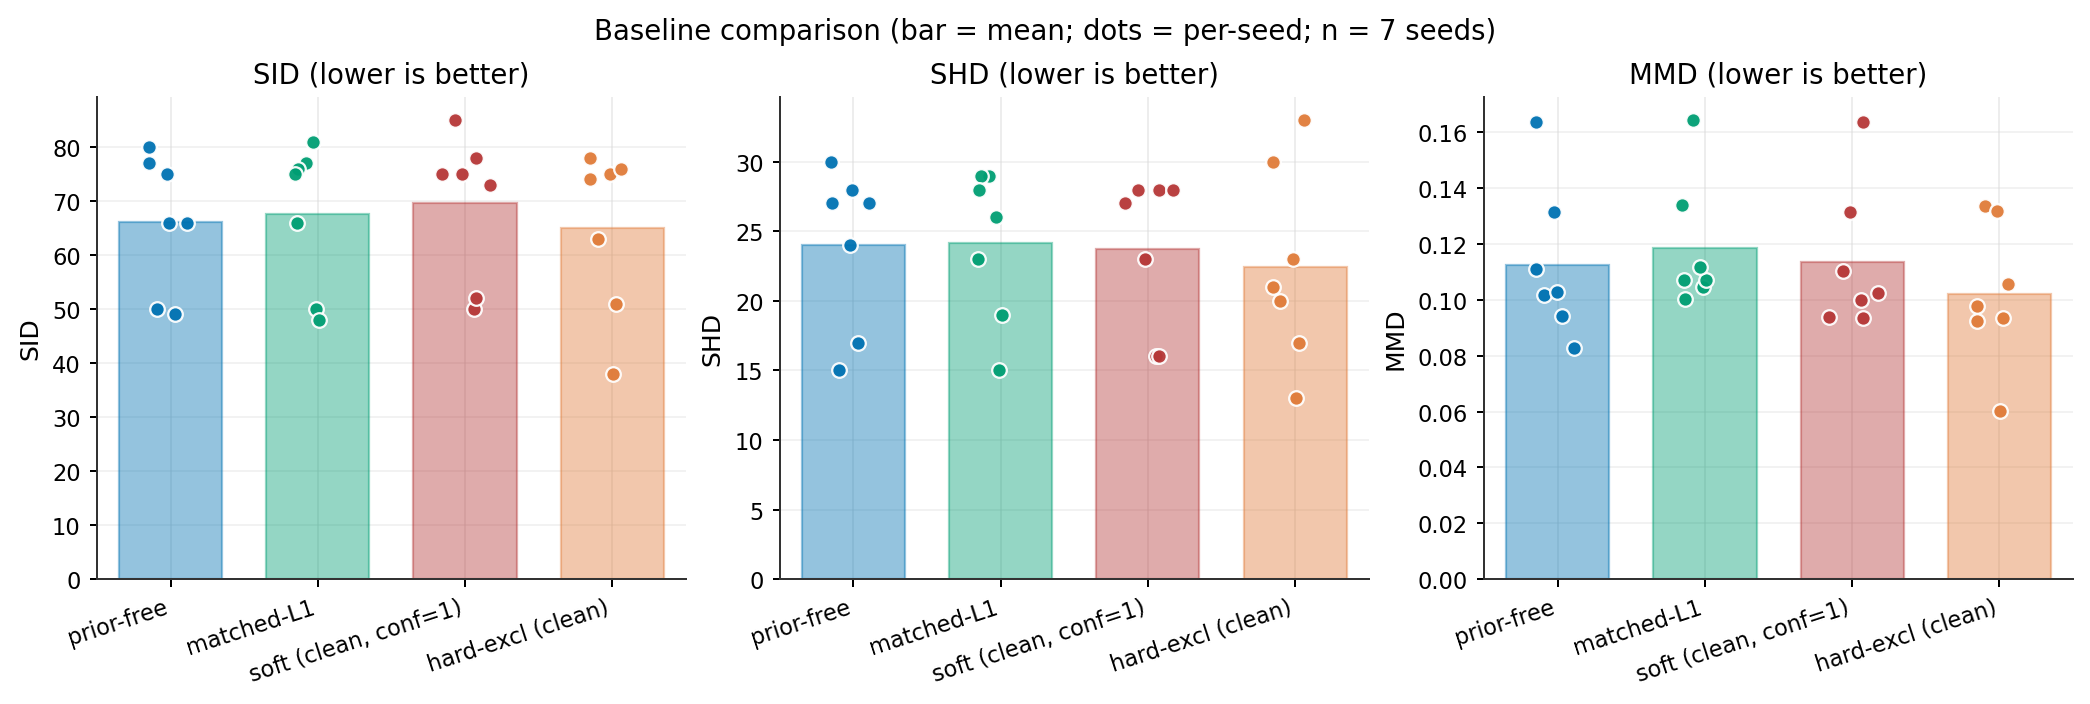

In [20]:
display(Markdown("Figure 1: SID / SHD / MMD by baseline condition."))
display(Image(filename=str(FIGURES_DIR / "fig01_baseline_comparison_sid_shd_mmd.png")))

## 4. Reference forbidden-edge suppression

Engagement of all four baseline conditions on the per-seed clean-soft forbidden-edge set.

In [21]:
ref_df = pd.read_csv(READOUT_DIR / "reference_forbidden_edge_comparison.csv")
display(Markdown("Reference forbidden-edge comparison (one row per seed and condition)."))
display(presentation_table(ref_df.head(20)))

Reference forbidden-edge comparison (one row per seed and condition).

,seed_value,condition_label,method_family,corruption_fraction,confidence,n_reference_forbidden_edges,mean_abs_w_reference_forbidden_edges,fraction_reference_forbidden_above_threshold,mean_abs_w_reference_non_targeted_edges,edge_count_from_thresholded_adjacency,sid,shd,mmd
0,501,prior_free,prior_free,—,—,10,0.2258,0.3,0.106,13,77,30,0.1639
1,501,matched_l1,matched_l1,—,—,10,0.1833,0.3,0.09736,12,77,29,0.1645
2,501,soft_frobenius_clean_conf1,soft_frobenius,0,1,10,0.06587,0.1,0.1003,11,78,28,0.1637
3,501,hard_exclusion_clean,hard_exclusion,0,—,10,0,0,0.09949,9,63,20,0.1338
4,502,prior_free,prior_free,—,—,10,0.08823,0.1,0.1143,12,50,15,0.1016
5,502,matched_l1,matched_l1,—,—,10,0.08572,0.1,0.1082,12,50,15,0.1045
6,502,soft_frobenius_clean_conf1,soft_frobenius,0,1,10,0.03913,0.1,0.1188,13,50,16,0.1001
7,502,hard_exclusion_clean,hard_exclusion,0,—,10,0,0,0.125,12,38,13,0.06008
8,503,prior_free,prior_free,—,—,10,0.05049,0.1,0.1576,17,66,27,0.08279
9,503,matched_l1,matched_l1,—,—,10,0.001137,0,0.1483,17,76,29,0.1002


Figure 2: mean |W| on reference forbidden edges by condition.

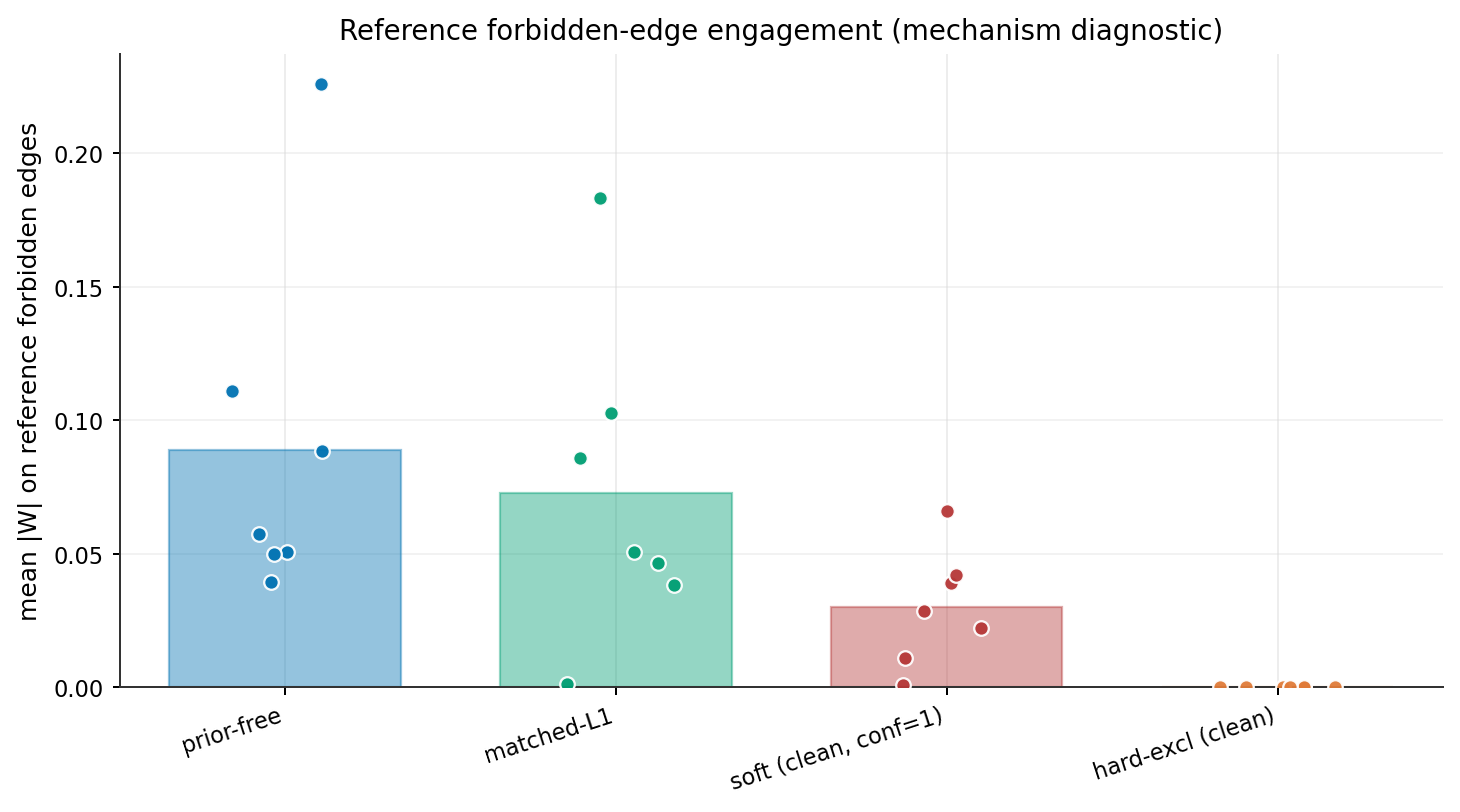

In [22]:
display(Markdown("Figure 2: mean |W| on reference forbidden edges by condition."))
display(Image(filename=str(FIGURES_DIR / "fig02_reference_forbidden_edge_suppression.png")))

## 5. Degradation curves

Hard-exclusion and soft-frobenius confidence levels across the corruption grid.

In [23]:
deg_df = pd.read_csv(READOUT_DIR / "degradation_summary.csv")
display(Markdown("Per-seed slope summaries by method_family, confidence, and metric."))
display(presentation_table(deg_df))

Per-seed slope summaries by method_family, confidence, and metric.

,method_family,confidence,metric,n_seed_slopes,mean_slope,std_slope,median_slope,min_slope,max_slope
0,hard_exclusion,—,sid,7,8.929,13.65,4.5,-1.5,38
1,hard_exclusion,—,shd,7,9.071,6.347,6.5,3,18
2,hard_exclusion,—,mmd,7,0.02657,0.01646,0.01973,0.00842,0.05891
3,hard_exclusion,—,edge_count_from_thresholded_adjacency,7,2.357,1.626,2,0.5,5
4,soft_frobenius,0,sid,7,0,0,0,0,0
5,soft_frobenius,0,shd,7,0,0,0,0,0
6,soft_frobenius,0,mmd,7,0,0,0,0,0
7,soft_frobenius,0,edge_count_from_thresholded_adjacency,7,0,0,0,0,0
8,soft_frobenius,0.25,sid,7,1,5.485,0,-8,10.5
9,soft_frobenius,0.25,shd,7,0.8571,1.029,1,-1,2


Figure 3: SID vs corruption_fraction.

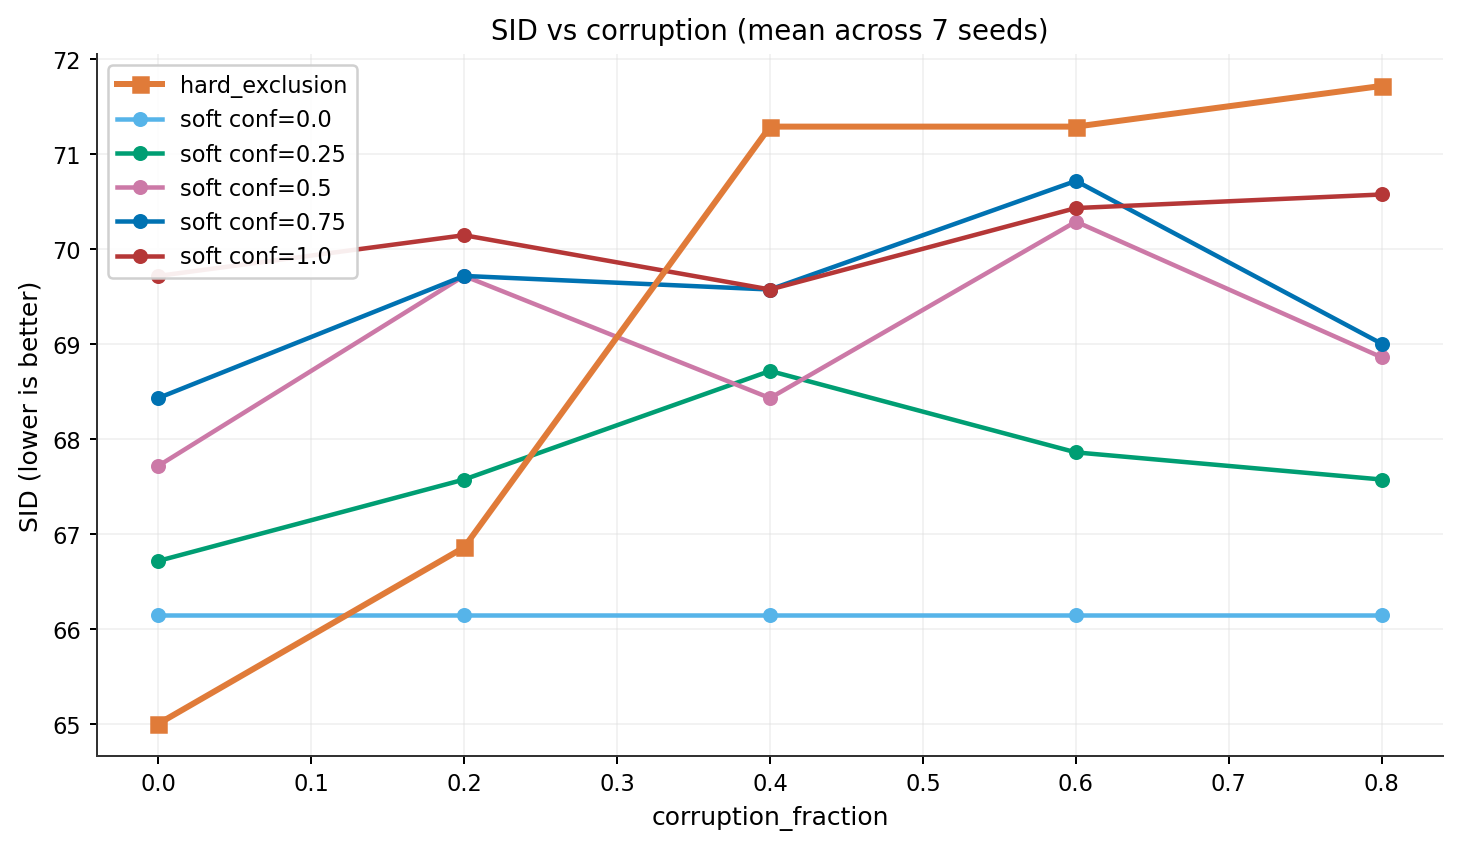

Figure 4: MMD vs corruption_fraction.

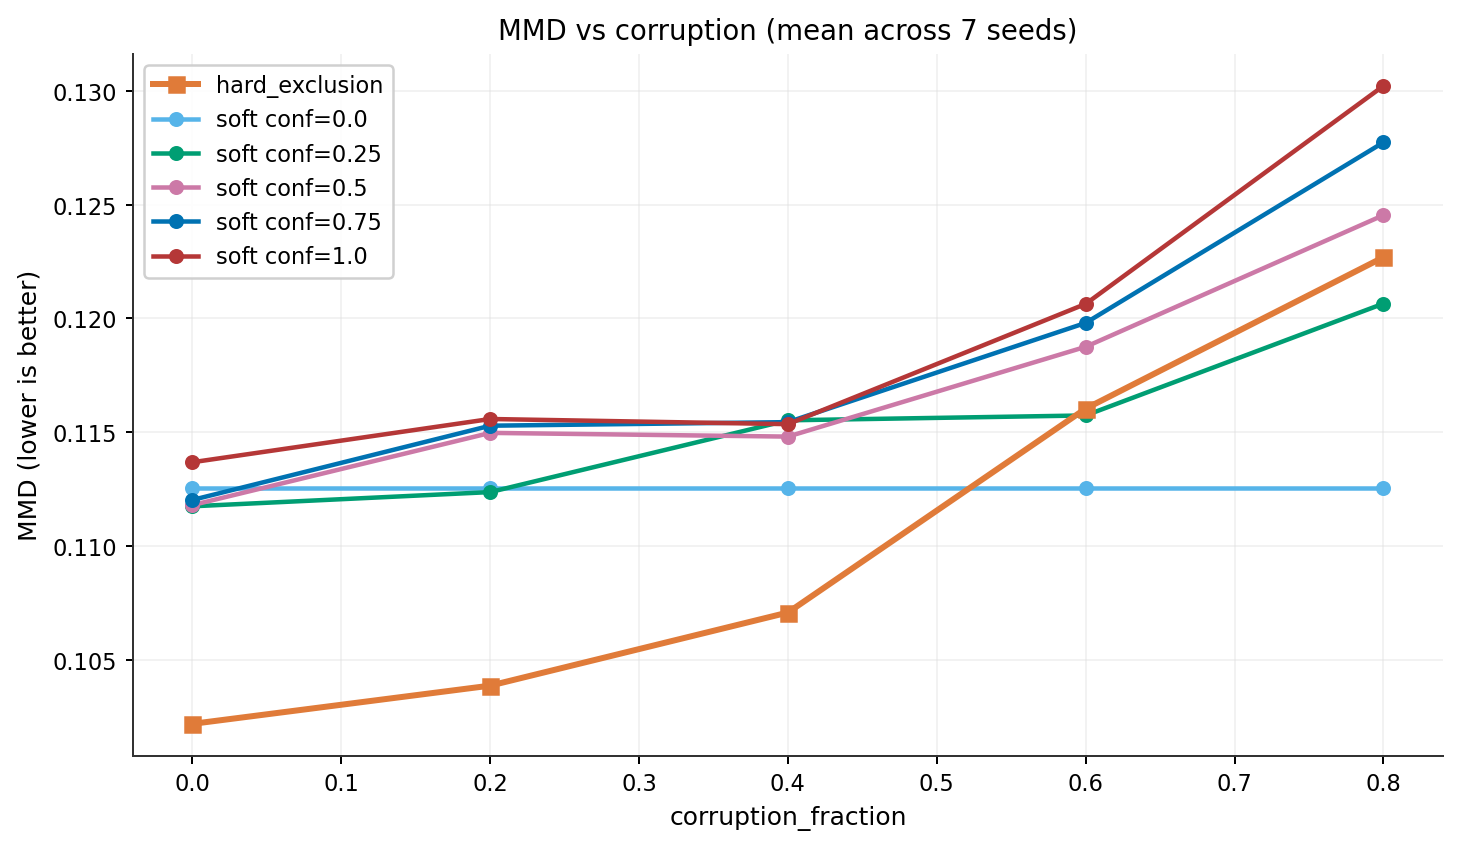

In [24]:
display(Markdown("Figure 3: SID vs corruption_fraction."))
display(Image(filename=str(FIGURES_DIR / "fig03_degradation_curves_sid.png")))
display(Markdown("Figure 4: MMD vs corruption_fraction."))
display(Image(filename=str(FIGURES_DIR / "fig04_degradation_curves_mmd.png")))

## 6. Soft-prior confidence x corruption heatmaps

Figure 5: mean SID across 7 seeds for soft_frobenius (corruption x confidence).

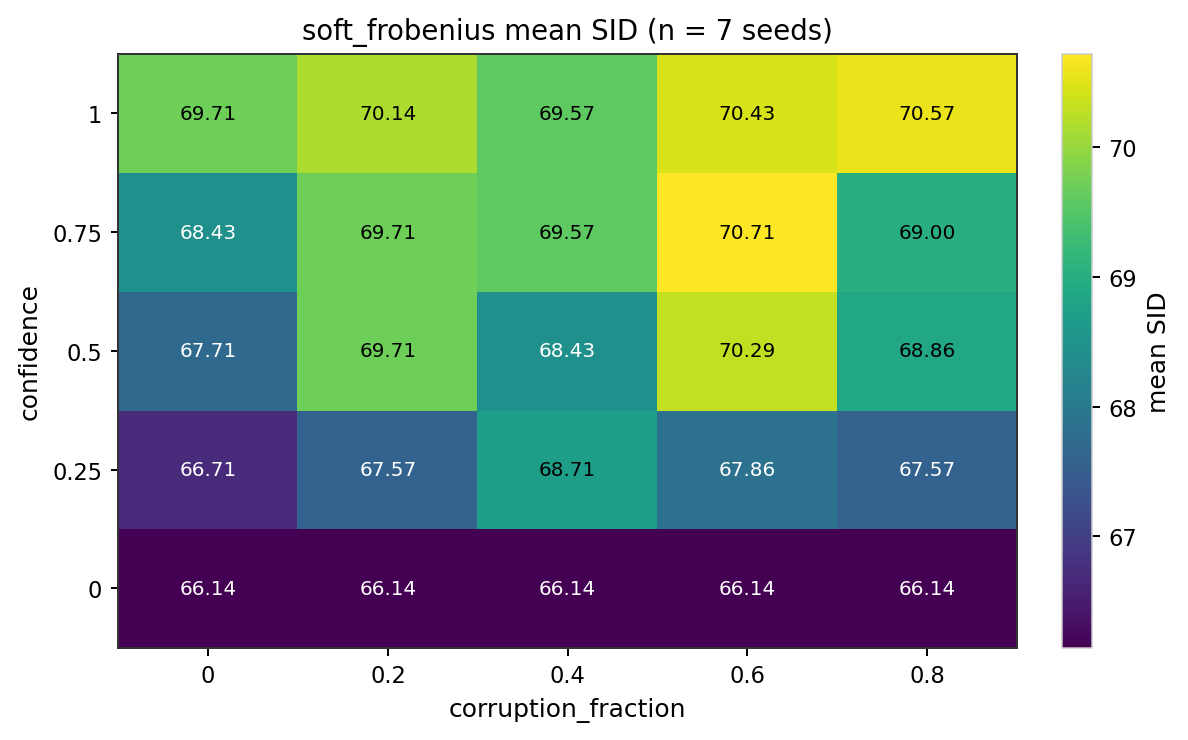

Figure 6: mean MMD across 7 seeds for soft_frobenius (corruption x confidence).

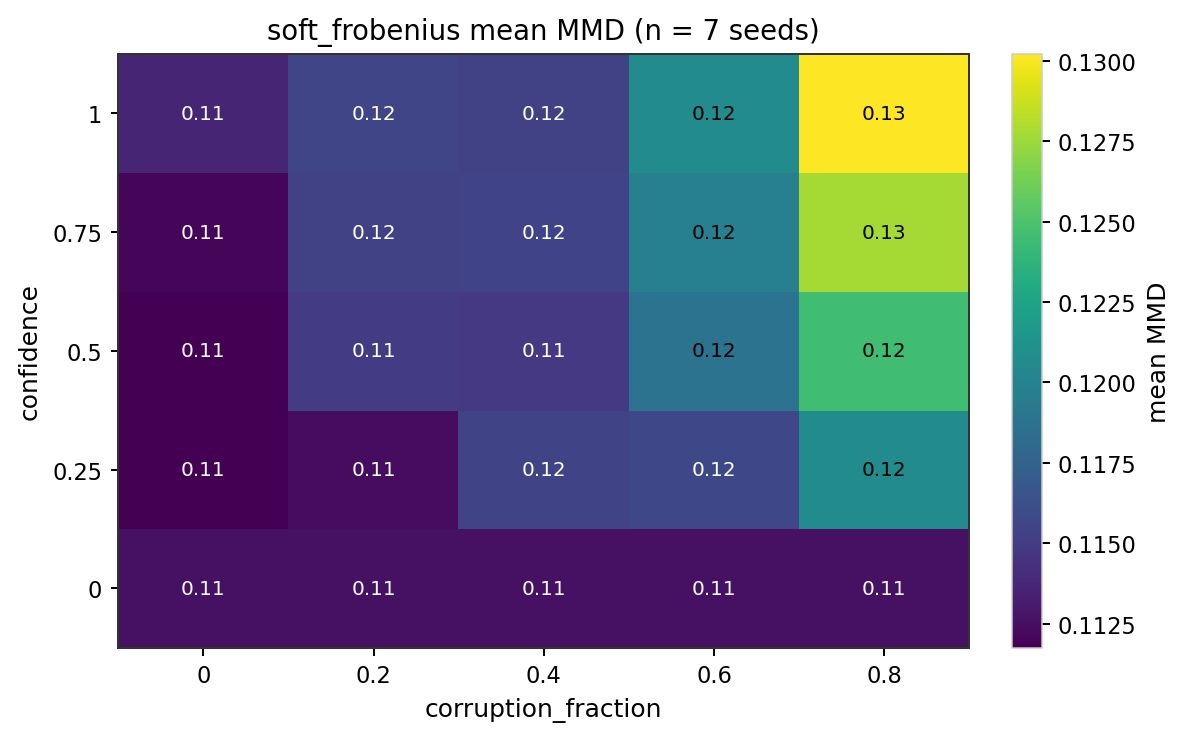

In [25]:
display(Markdown("Figure 5: mean SID across 7 seeds for soft_frobenius (corruption x confidence)."))
display(Image(filename=str(FIGURES_DIR / "fig05_soft_frobenius_sid_heatmap.png")))
display(Markdown("Figure 6: mean MMD across 7 seeds for soft_frobenius (corruption x confidence)."))
display(Image(filename=str(FIGURES_DIR / "fig06_soft_frobenius_mmd_heatmap.png")))

## 7. SID-MMD relationship

In [26]:
corr_df = pd.read_csv(READOUT_DIR / "metric_correlations.csv")
display(Markdown("Metric correlation table (overall and per method_family)."))
display(presentation_table(corr_df))

Metric correlation table (overall and per method_family).

,group_label,method_family,x_metric,y_metric,n,pearson,spearman,kendall_tau_b
0,all,—,sid,mmd,224,0.5006,0.5491,0.3681
1,all,—,shd,mmd,224,0.3398,0.3618,0.246
2,all,—,edge_count_from_thresholded_adjacency,mmd,224,-0.391,-0.2476,-0.194
3,all,—,sid,shd,224,0.8666,0.7701,0.5649
4,method_family:hard_exclusion,hard_exclusion,sid,mmd,35,0.4963,0.4027,0.2953
5,method_family:hard_exclusion,hard_exclusion,shd,mmd,35,0.2707,0.2342,0.182
6,method_family:hard_exclusion,hard_exclusion,edge_count_from_thresholded_adjacency,mmd,35,-0.2633,-0.2116,-0.1235
7,method_family:hard_exclusion,hard_exclusion,sid,shd,35,0.8253,0.8561,0.6552
8,method_family:matched_l1,matched_l1,sid,mmd,7,0.4258,0.4643,0.3333
9,method_family:matched_l1,matched_l1,shd,mmd,7,0.3285,0.2162,0.1952


Figure 7: SID vs MMD scatter, coloured by method_family.

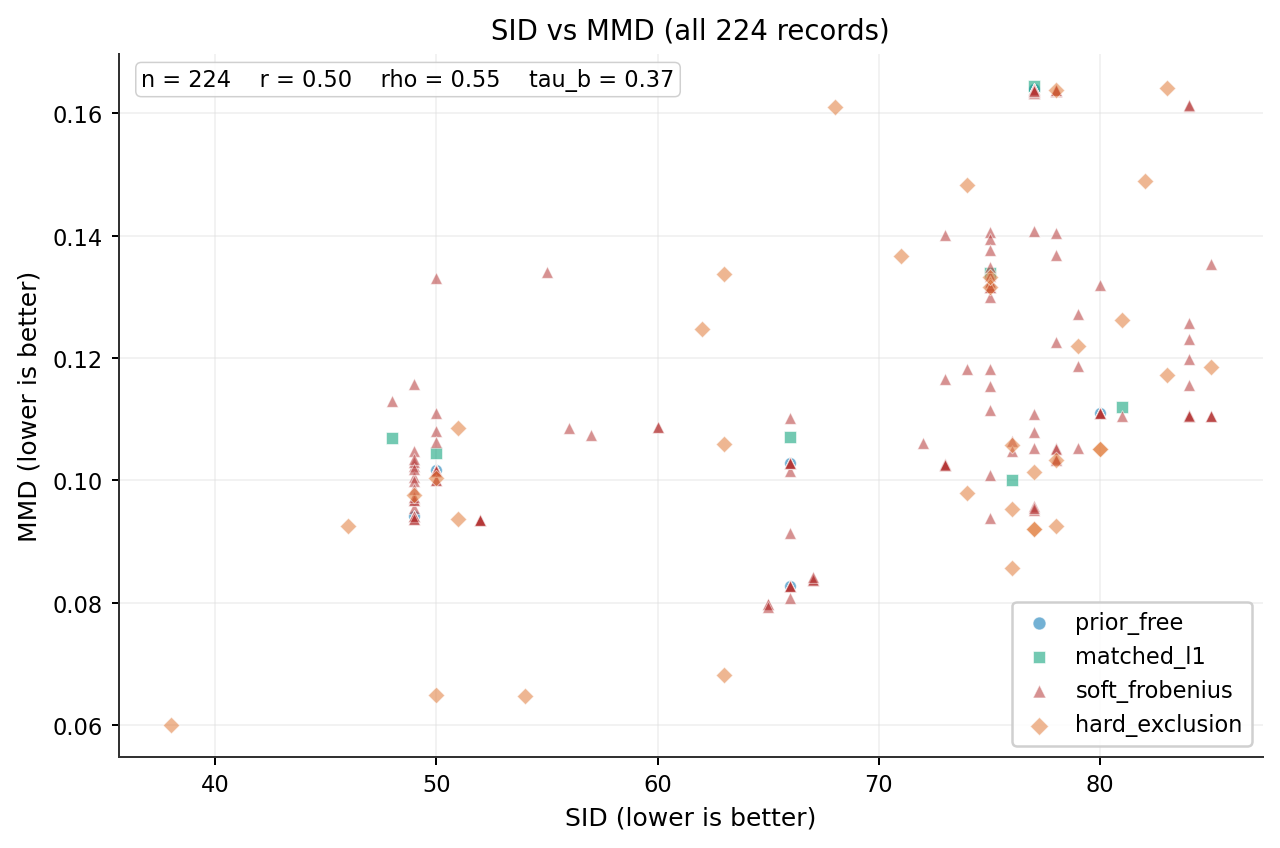

In [27]:
display(Markdown("Figure 7: SID vs MMD scatter, coloured by method_family."))
display(Image(filename=str(FIGURES_DIR / "fig07_sid_vs_mmd_correlation.png")))

## 8. Edge-count / engagement diagnostic

In [28]:
eng_df = pd.read_csv(READOUT_DIR / "forbidden_edge_engagement_summary.csv")
display(Markdown("Forbidden-edge engagement summary (per cell)."))
display(presentation_table(eng_df))

Forbidden-edge engagement summary (per cell).

,method_family,corruption_fraction,confidence,n,mean_targeted_abs_w_mean,std_targeted_abs_w_mean,median_targeted_abs_w_mean,mean_fraction_targeted_above_threshold,std_fraction_targeted_above_threshold,median_fraction_targeted_above_threshold,mean_non_targeted_abs_w_mean,std_non_targeted_abs_w_mean,median_non_targeted_abs_w_mean,mean_edge_count,std_edge_count,median_edge_count
0,hard_exclusion,0,—,7,0,0,0,0,0,0,0.1333,0.02075,0.1343,13.43,2.573,13
1,hard_exclusion,0.2,—,7,0,0,0,0,0,0,0.133,0.01981,0.1307,14.14,2.795,14
2,hard_exclusion,0.4,—,7,0,0,0,0,0,0,0.1369,0.01539,0.1327,14.71,2.289,15
3,hard_exclusion,0.6,—,7,0,0,0,0,0,0,0.1386,0.01241,0.1362,14.57,2.37,13
4,hard_exclusion,0.8,—,7,0,0,0,0,0,0,0.1386,0.02194,0.1387,15.57,2.936,17
5,matched_l1,—,—,7,—,—,—,—,—,—,—,—,—,14.29,2.43,13
6,prior_free,—,—,7,—,—,—,—,—,—,—,—,—,14.71,2.289,14
7,soft_frobenius,0,0,7,0.08883,0.06541,0.05741,0.1286,0.07559,0.1,0.1302,0.0183,0.1271,14.71,2.289,14
8,soft_frobenius,0,0.25,7,0.06205,0.03823,0.04424,0.1,0.05774,0.1,0.1299,0.02104,0.1276,14.57,2.76,14
9,soft_frobenius,0,0.5,7,0.04755,0.0274,0.03719,0.04286,0.05345,0,0.1312,0.02146,0.128,14.29,2.984,13


Figure 8: edge-count and reference-forbidden engagement diagnostic.

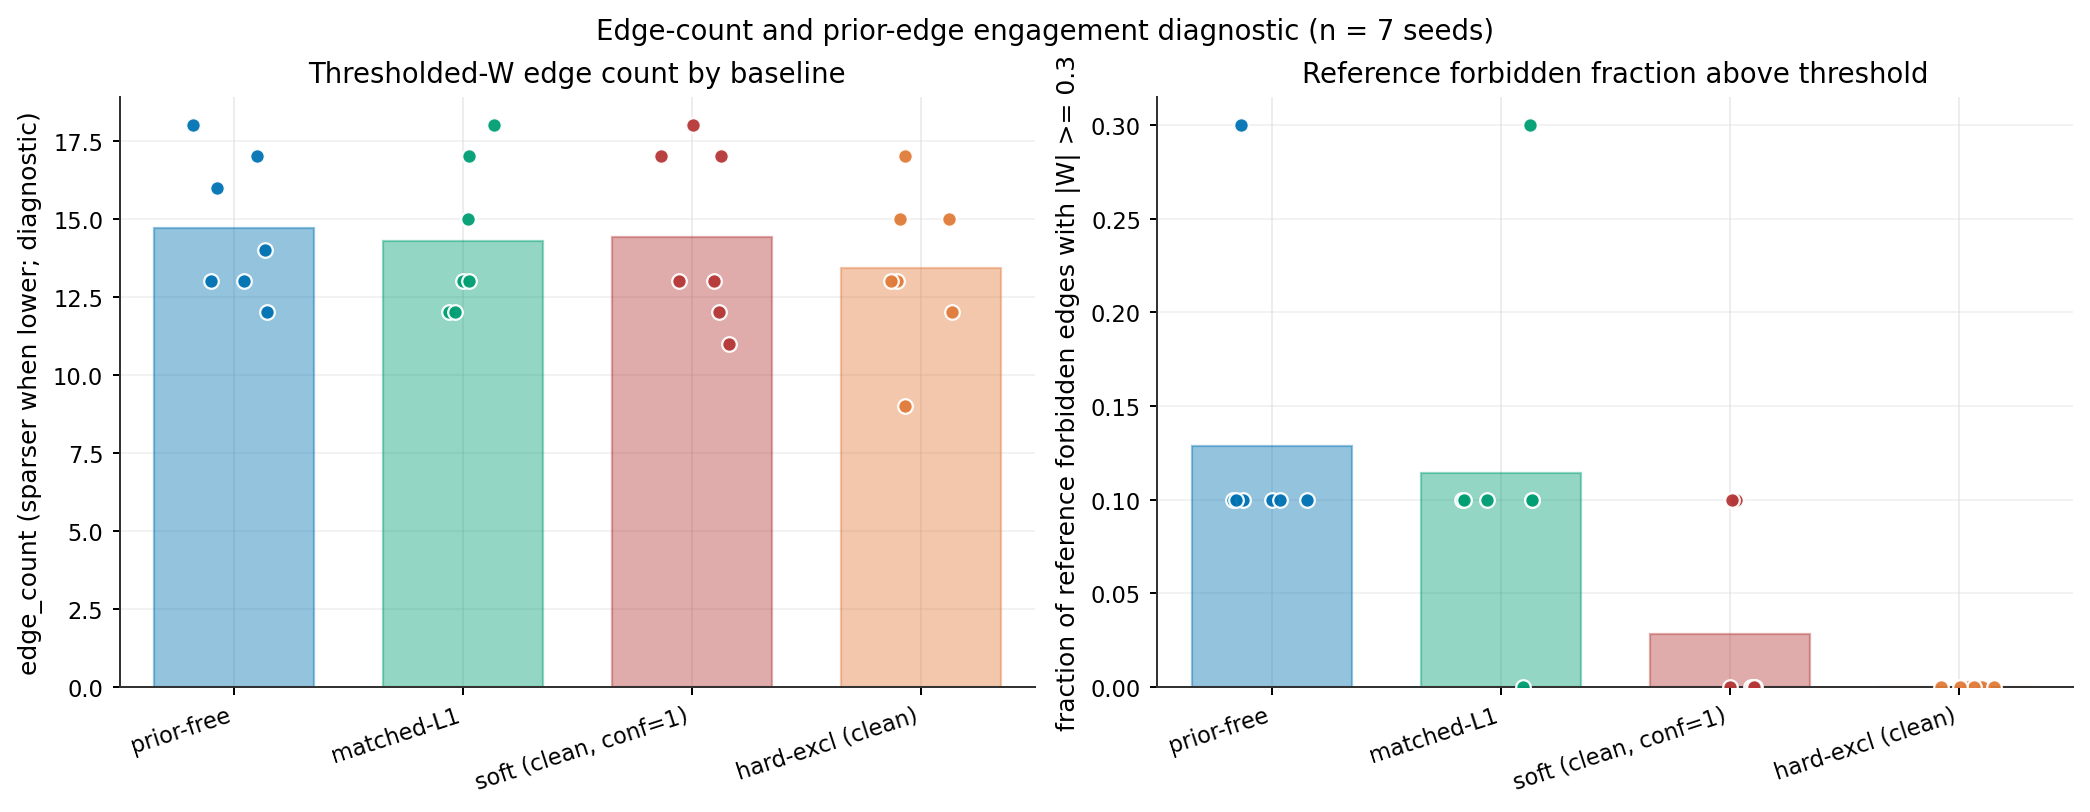

In [29]:
display(Markdown("Figure 8: edge-count and reference-forbidden engagement diagnostic."))
display(Image(filename=str(FIGURES_DIR / "fig08_edge_count_and_engagement_diagnostic.png")))

## 9. Output manifest

Generated artefacts on disk.

In [30]:
for p in sorted((READOUT_DIR / "figures").glob("fig*.png")):
    print(p)
summary_md = READOUT_DIR / "readout_summary.md"
if summary_md.exists():
    print(summary_md)
print("All artefacts saved. Thesis interpretation is separate.")

c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout\figures\fig01_baseline_comparison_sid_shd_mmd.png
c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout\figures\fig02_reference_forbidden_edge_suppression.png
c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout\figures\fig03_degradation_curves_sid.png
c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout\figures\fig04_degradation_curves_mmd.png
c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout\figures\fig05_soft_frobenius_sid_heatmap.png
c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\main_study\main_evaluation\864fe6722256\readout\figures\fig06_soft_frobenius_m